In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
TONE_DIR = r'C:\Users\A S U S\Documents\skin_dataset\Skintone'

In [3]:
classes = [d for d in os.listdir(TONE_DIR)
           if os.path.isdir(os.path.join(TONE_DIR, d))]

for cls in classes:
    path = os.path.join(TONE_DIR, cls)
    num_images = len([f for f in os.listdir(path)
                      if f.lower().endswith(('.png','.jpg','.jpeg'))])
    print(f"{cls}: {num_images} images")

dark: 8640 images
light: 9769 images
mid-dark: 10576 images
mid-light: 6844 images


In [4]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 20
MODEL_OUT = 'model_skintone.h5'

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True
)

In [6]:
train_gen = train_datagen.flow_from_directory(
    TONE_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TONE_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 28665 images belonging to 4 classes.
Found 7164 images belonging to 4 classes.


In [7]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0367838541666667), 1: np.float64(0.9168692425793245), 2: np.float64(0.8469743529133672), 3: np.float64(1.308665084002922)}


In [9]:
base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE,3)
)

base.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=base.input, outputs=output)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [13]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 1360s 2s/step - accuracy: 0.8657 - loss: 0.3150 - val_accuracy: 0.8294 - val_loss: 0.3842 - learning_rate: 9.0000e-05
Epoch 2/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 1690s 2s/step - accuracy: 0.8661 - loss: 0.3130 - val_accuracy: 0.8386 - val_loss: 0.3728 - learning_rate: 9.0000e-05
Epoch 3/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 1087s 1s/step - accuracy: 0.8648 - loss: 0.3154 - val_accuracy: 0.8300 - val_loss: 0.3861 - learning_rate: 9.0000e-05
Epoch 4/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 754s 841ms/step - accuracy: 0.8644 - loss: 0.3149 - val_accuracy: 0.8283 - val_loss: 0.3957 - learning_rate: 9.0000e-05
Epoch 5/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 753s 841ms/step - accuracy: 0.8619 - loss: 0.3193 - val_accuracy: 0.8395 - val_loss: 0.3626 - learning_rate: 9.0000e-05
Epoch 6/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 753s 840ms/step - accuracy: 0.8670 - loss: 0.3137 - val_accuracy: 0.8402 - val_loss: 0.3695 - learning_rate: 9.0000e-05
Epoch 7/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 755s 8

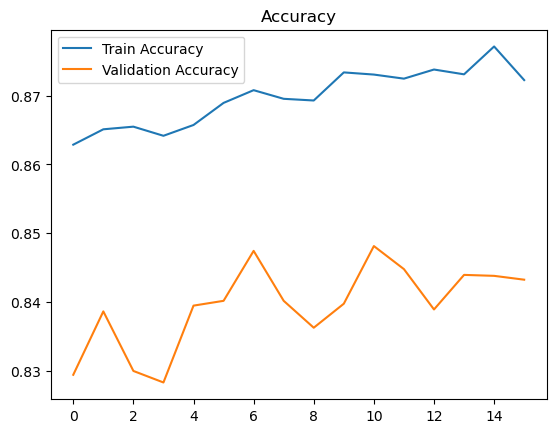

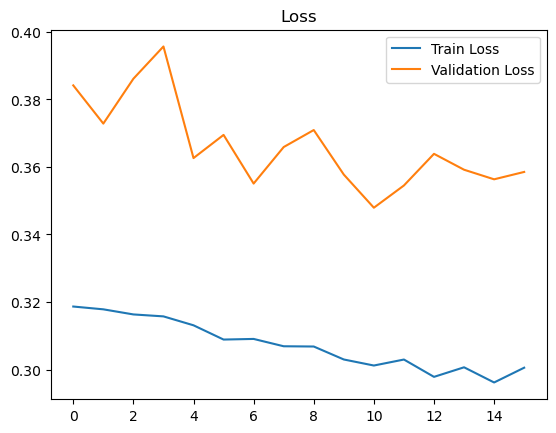

In [14]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [15]:
loss, acc = model.evaluate(val_gen)
print("Validation Accuracy:", acc)

224/224 ━━━━━━━━━━━━━━━━━━━━ 160s 714ms/step - accuracy: 0.8448 - loss: 0.3729
Validation Accuracy: 0.8478503823280334


In [16]:
model.save(MODEL_OUT)

with open('label_map_skintone.json','w') as f:
    json.dump(train_gen.class_indices, f)

print("Model saved:", MODEL_OUT)

Model saved: model_skintone.h5
